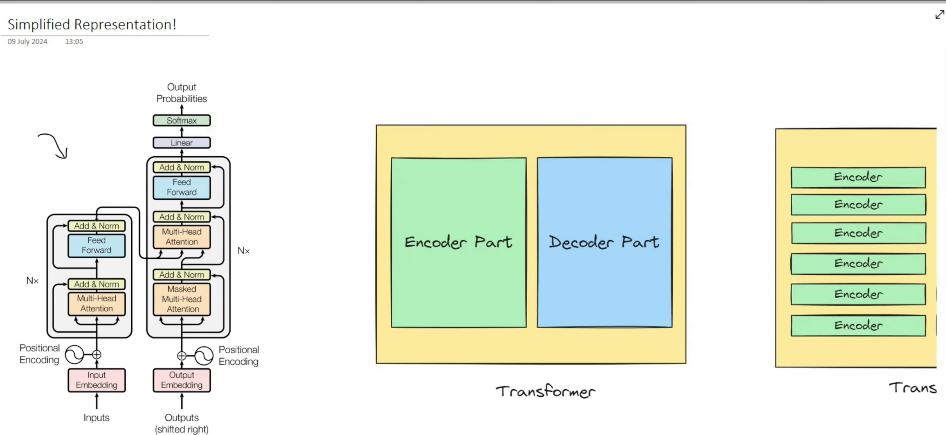

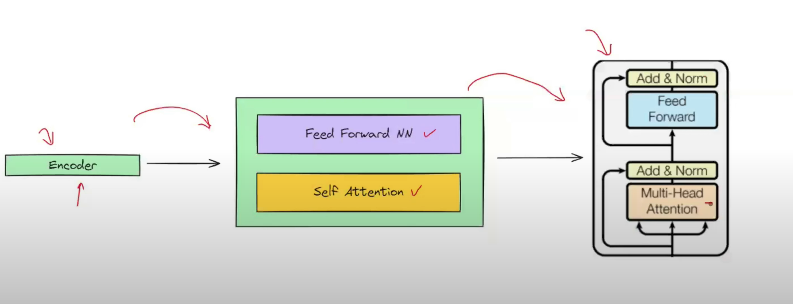

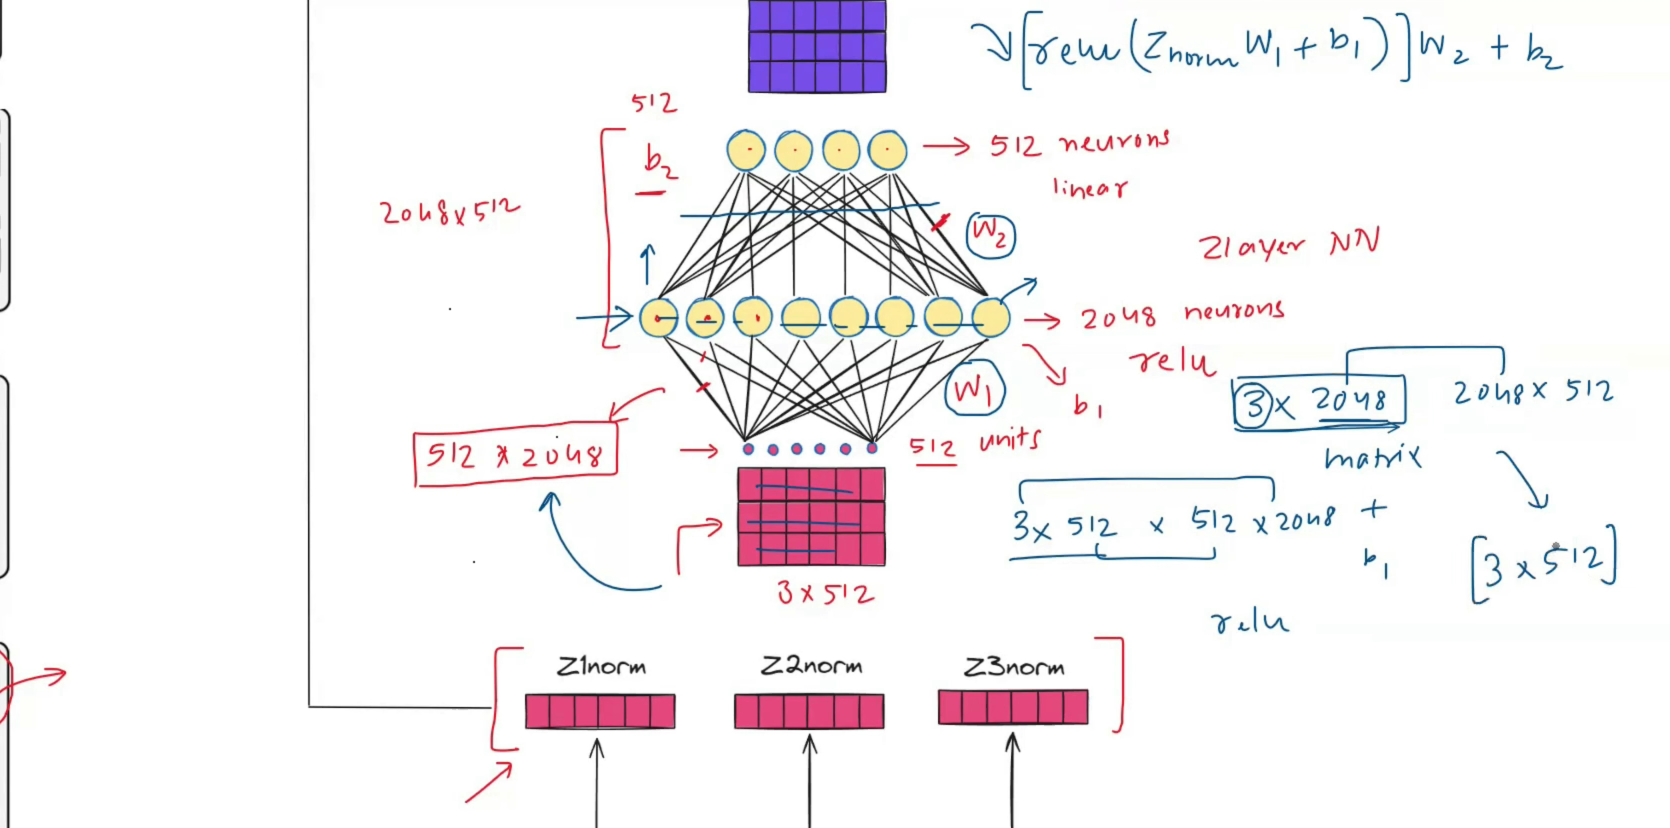

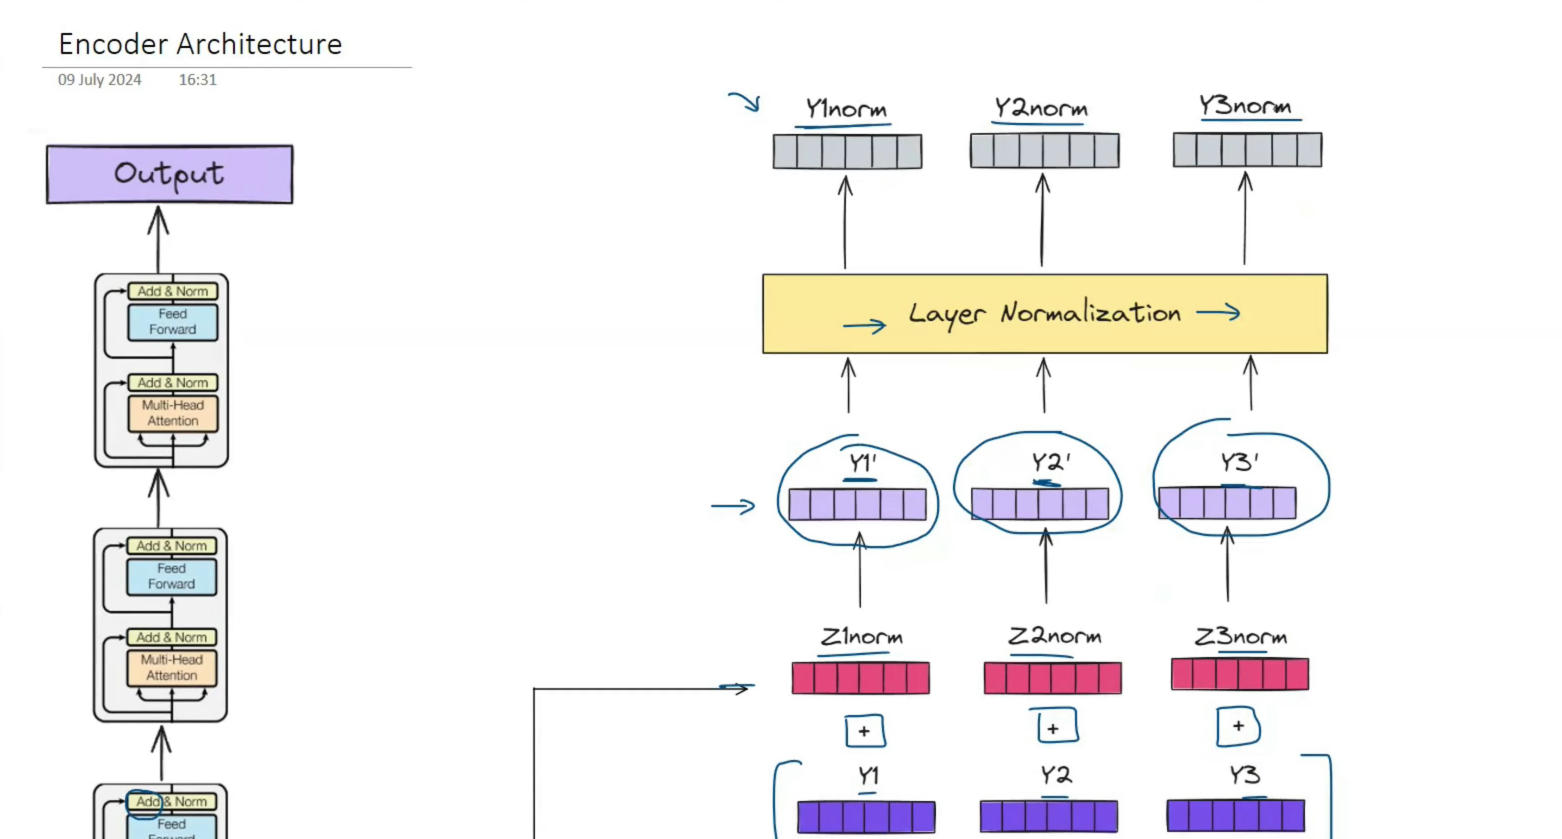

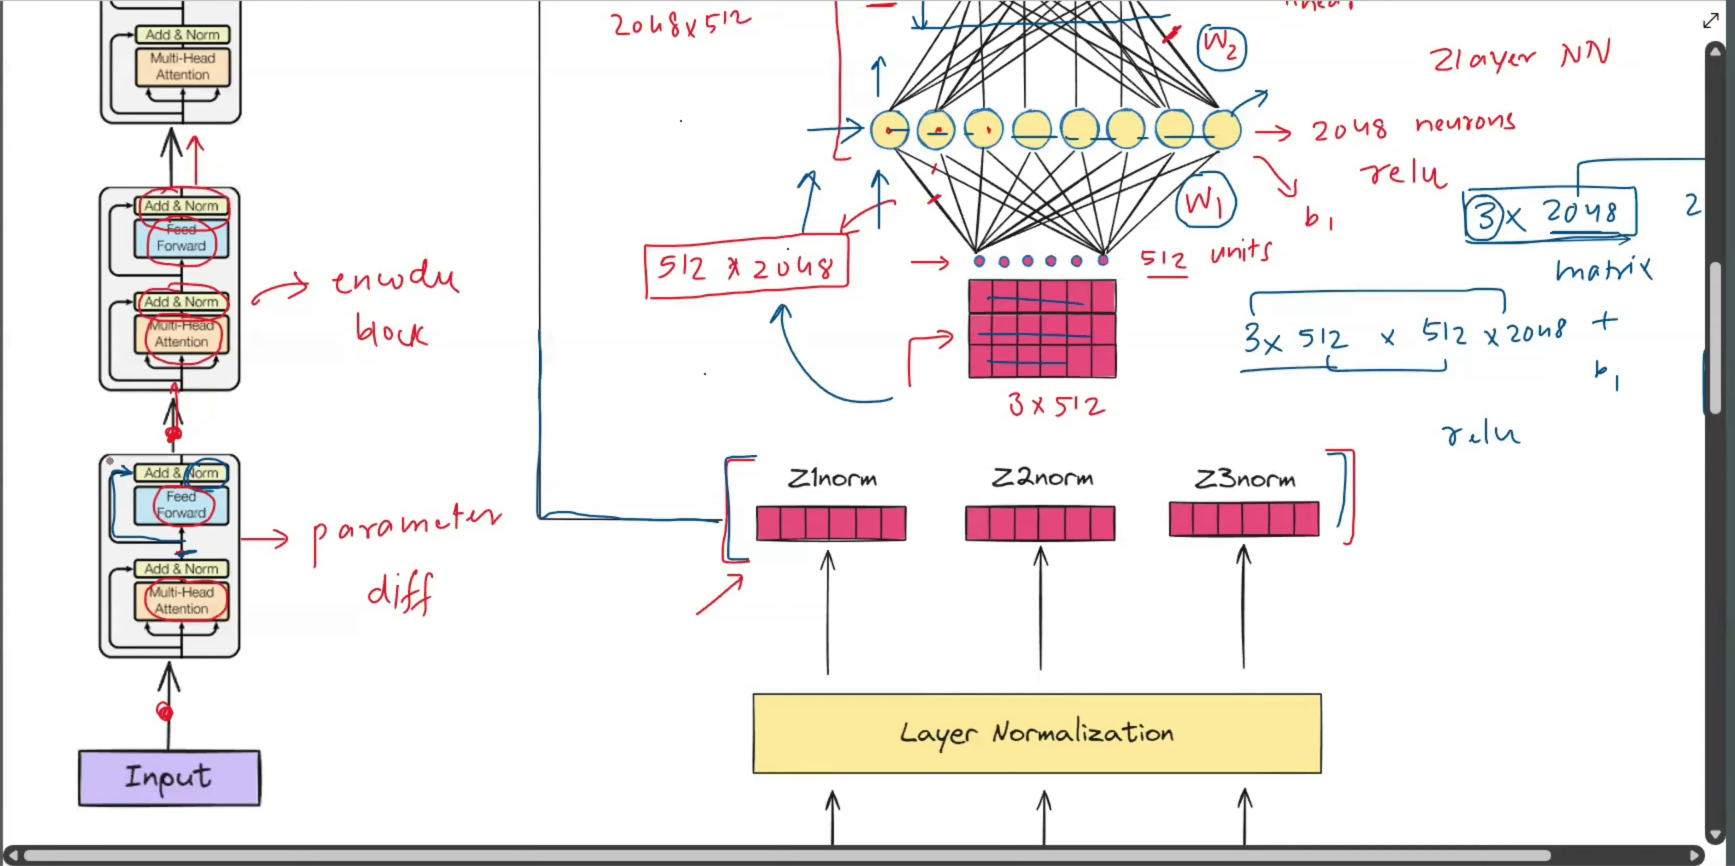

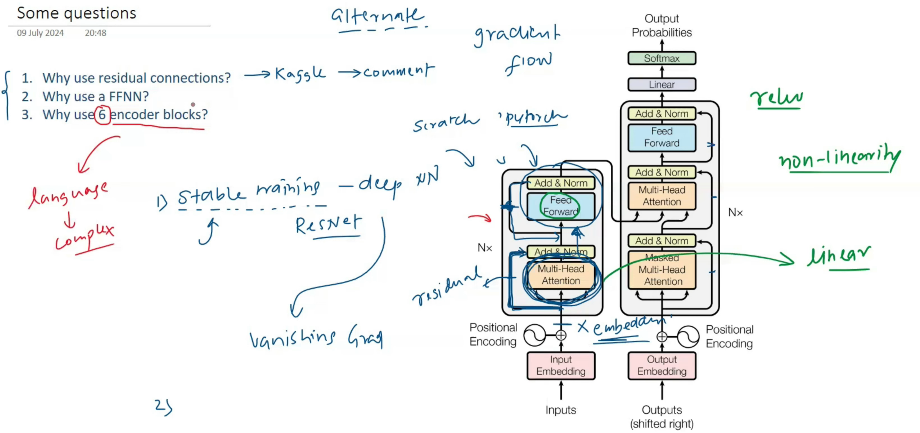

The Transformer Encoder architecture is designed to process input sequences and generate contextualized representations. The process involves several key steps, starting with input preparation, moving through stacked encoder blocks, and finally producing an output that is then fed into the decoder.

### Overall Structure of the Transformer Encoder

The Transformer architecture is broadly divided into two main parts: an **Encoder** and a **Decoder**. This video focuses specifically on the Encoder part.

The Encoder itself is composed of **multiple identical Encoder blocks**. In the original "Attention Is All You Need" paper, **six such Encoder blocks** were used, and this number was determined empirically for optimal results. The crucial insight is that **all these blocks are architecturally identical**, meaning if you understand one block, you understand the entire Encoder. The output of one Encoder block serves as the input for the subsequent block, and this sequence continues until the output of the sixth block is passed to the Decoder.

### Step 1: Input Processing Before the Encoder Blocks

Before any data enters the main Encoder blocks, three critical operations are performed within an "input block":

1.  **Tokenization:**
    *   **What:** The input sentence (e.g., "How are you") is broken down into individual tokens, typically words.
    *   **Why:** Machines cannot directly process human language. Tokenization provides discrete units for further processing.
2.  **Text Vectorization (Embeddings):**
    *   **What:** Each token (word) is converted into a numerical vector. This is done using an embedding layer, which generates a **512-dimensional vector** for each word.
    *   **Why:** Words must be represented numerically for machine processing.
    *   **Intuition/Problem:** A key issue with simple embeddings is that they are **context-agnostic**. For example, the word "bank" in "river bank" and "money bank" would have the same embedding, even though their meanings are different based on context. This problem is addressed later by Self-Attention.
3.  **Positional Encoding:**
    *   **What:** A 512-dimensional positional vector is generated for each position in the sentence (e.g., for position 1, 2, 3, etc.). These positional vectors are then **added** to their corresponding word embedding vectors. The resulting vectors (e.g., x1, x2, x3) are still 512-dimensional and serve as the input to the first Encoder block.
    *   **Why:** Traditional machine learning models and even early attention mechanisms do not inherently understand the order of words in a sentence. Adding positional encoding explicitly injects this **sequential information**, which is crucial for understanding sentence semantics.

### Step 2: Inside a Single Encoder Block

Each Encoder block consists of two main sub-blocks: a **Multi-Head Attention block** and a **Feed-Forward Neural Network (FFN) block**, with **Add & Norm** layers connecting them and at the output.

Let's trace the journey of the input vectors (x1, x2, x3) through an Encoder block:

#### 2.1. Multi-Head Attention Block

*   **What:** The 512-dimensional input vectors (x1, x2, x3) enter the Multi-Head Attention block. This block performs complex calculations involving Query, Key, and Value vectors (details of which are covered in prerequisite videos). The output consists of new vectors (z1, z2, z3), which are also **512-dimensional**.
*   **Why Self-Attention/Multi-Head Attention:**
    *   **Contextual Embeddings:** The primary purpose is to address the limitation of initial word embeddings being context-agnostic. Self-Attention allows each word's representation to be influenced by all other words in the sentence, creating **contextually aware embeddings**. For instance, the embedding for "bank" would differ based on "river" or "money" in the sentence.
    *   **Enhanced Diversity (Multi-Head):** Multi-Head Attention involves multiple "heads" or parallel self-attention mechanisms. This allows the model to capture **different aspects of relationships** between words simultaneously, leading to a richer and more diverse contextual understanding than a single self-attention mechanism.

#### 2.2. Add & Norm (After Multi-Head Attention)

*   **What:** The output of the Multi-Head Attention (z1, z2, z3) is then processed by an "Add & Norm" layer. This involves two sub-operations:
    *   **Residual Connection ("Add"):** The original input to the Multi-Head Attention block (x1, x2, x3) is **bypassed** and directly added to its output (z1, z2, z3). This results in new vectors (z1', z2', z3'), which are still 512-dimensional.
    *   **Layer Normalization ("Norm"):** The newly added vectors (z1', z2', z3') are then subjected to Layer Normalization. For each 512-dimensional vector, its 512 numbers are normalized by calculating their mean and standard deviation. The output is a set of normalized vectors (z1_norm, z2_norm, z3_norm), maintaining the 512-dimension.
*   **Why Residual Connections:**
    *   **Speculation/Intuition (not explicitly in original paper):**
        *   **Stable Training & Vanishing Gradients:** In very deep neural networks (like the Transformer with its stacked blocks), there's a risk of **vanishing gradients**, where gradients become too small to effectively update parameters in earlier layers. Residual connections (also called skip connections) provide **alternate pathways for gradient flow**, ensuring that gradients don't shrink excessively and allowing for more stable training. This concept was notably introduced in ResNet architectures.
        *   **Preserving Original Features:** If a transformation (like Multi-Head Attention) doesn't perform well or even degrades the quality of the embeddings, the residual connection ensures that the model can still **fall back on the original input features**. It provides a direct path for the initial, potentially "good enough" features to propagate through the network.
*   **Why Layer Normalization:**
    *   **Stabilize Training Process:** The outputs of operations like Multi-Head Attention can vary widely in range. Neural network training is generally more stable when numerical values are kept within a **small, consistent range**. Layer Normalization standardizes these values, contributing to more robust and faster training.

#### 2.3. Feed-Forward Neural Network (FFN) Block

*   **What:** The normalized vectors (z1_norm, z2_norm, z3_norm) from the previous step enter the FFN block. This FFN is a **two-layer neural network**:
    *   The first layer has **2048 neurons** and uses a **ReLU activation function**.
    *   The second layer has **512 neurons** and uses a **linear activation function**.
    *   Input vectors are processed as a batch, where their dimension is first **increased from 512 to 2048** (by multiplying with weights W1 and adding biases b1) and then **reduced back to 512** (by multiplying with weights W2 and adding biases b2). The output consists of new 512-dimensional vectors (y1, y2, y3).
*   **Why Feed-Forward Neural Network:**
    *   **Speculation/Intuition (active research area):**
        *   **Introducing Non-Linearity:** Multi-Head Attention, despite its complexity, is primarily a linear operation. The FFN, especially with its ReLU activation in the first layer, introduces **non-linearity** into the model. This non-linearity allows the model to capture more complex, non-linear patterns and relationships within the data that linear transformations alone might miss.
        *   **Key-Value Memories (Research Perspective):** A paper suggests that FFN layers might function as **key-value memories**. In this view, "keys" correlate with textual patterns in training examples, and "values" induce a distribution over the output vocabulary. This implies that FFNs might be storing and recalling specific patterns learned during training. The source notes that this is an active area of research, and the exact role is still "under-explored".
        *   **Parameter Contribution:** FFN layers constitute about **two-thirds of the Transformer model's parameters**, highlighting their significant role even if their exact function is not fully understood.

#### 2.4. Add & Norm (After FFN)

*   **What:** Similar to the previous "Add & Norm" layer, the output of the FFN (y1, y2, y3) is processed:
    *   **Residual Connection ("Add"):** The input to the FFN (z1_norm, z2_norm, z3_norm) is bypassed and directly added to the FFN's output (y1, y2, y3). This creates new vectors (y1', y2', y3').
    *   **Layer Normalization ("Norm"):** These vectors are then layer-normalized to produce the final output of the Encoder block (y1_norm, y2_norm, y3_norm), still 512-dimensional.
*   **Why:** The reasoning for residual connections and layer normalization here is the **same as previously discussed** (stable training, preventing vanishing gradients, preserving features, and normalizing value ranges).

### Step 3: Stacking Encoder Blocks

*   **What:** The output of the first Encoder block (y1_norm, y2_norm, y3_norm) becomes the **input for the second Encoder block**. This process is repeated for all six Encoder blocks.
*   **Parameter Distinction:** It's important to note that while the architecture of each Encoder block is identical, the **parameters (weights and biases) within each block are distinct**. They are learned independently during the backpropagation process.
*   **Why Multiple Blocks:**
    *   **Representational Power for Language Complexity:** Human language is incredibly complex and nuanced. A single Encoder block is **insufficient to develop a satisfactory understanding**. Stacking multiple blocks creates a "deep" neural network, significantly increasing the model's **representational power**.
    *   **Uncovering Hidden Patterns:** Deep learning's core philosophy is to stack layers to create deeper representations, allowing the model to **decode hidden patterns and extract more abstract features** from the data. This layered approach enables the Transformer to learn intricate linguistic relationships.
    *   **Empirical Best Results:** While the exact number can vary based on application, **six blocks were found to give the best empirical results** for the original Transformer.

### Final Encoder Output

After the input sequence has passed through all six stacked Encoder blocks, the final output (which consistently maintains the **3x512 dimension** for our example sentence "How are you") is then sent to the Decoder for the next stage of processing.

The Transformer Encoder architecture is a crucial part of the overall Transformer model, designed to process input sequences and generate rich, contextualized representations. The video provides a detailed breakdown of its structure, the steps involved, and the intuition behind its various components.

### Overall Transformer Architecture and Encoder Focus

**Q1: What is the overall structure of the Transformer architecture?**
A1: The Transformer architecture is primarily divided into two main parts: an **Encoder** and a **Decoder**. This video specifically focuses on detailing the **Encoder part**.

**Q2: How many Encoder blocks are there, and are they identical?**
A2: The Encoder consists of **multiple identical Encoder blocks**. In the original "Attention Is All You Need" paper, **six Encoder blocks** were used, a number determined empirically to achieve the best results. All these blocks are **architecturally identical**, meaning understanding one block is sufficient to understand the entire Encoder. The output of one Encoder block serves as the input for the subsequent block.

### Step 1: Input Processing Before the Encoder Blocks

**Q3: What are the three critical operations performed before data enters the main Encoder blocks?**
A3: Before entering the Encoder blocks, the input undergoes three important operations within an "input block":
1.  **Tokenization**: The input sentence (e.g., "How are you") is broken down into individual tokens, typically words. This is necessary because machines cannot directly process human language.
2.  **Text Vectorization (Embeddings)**: Each token is converted into a numerical vector using an embedding layer. For example, each word is transformed into a **512-dimensional vector**.
    *   **Why**: Words need to be represented numerically for machine processing.
    *   **Intuition/Problem**: A key issue here is that simple word embeddings are **context-agnostic**. The word "bank" would have the same embedding regardless of whether it refers to a "river bank" or a "money bank," even though their meanings differ based on context. This problem is later addressed by Self-Attention.
3.  **Positional Encoding**: A 512-dimensional positional vector is generated for each word's position in the sentence. These positional vectors are then **added** to their corresponding word embedding vectors. The resulting vectors (e.g., x1, x2, x3) are still 512-dimensional and serve as the input to the first Encoder block.
    *   **Why**: Unlike recurrent neural networks, the Transformer's attention mechanism does not inherently understand word order. **Positional encoding explicitly injects sequential information** into the embeddings, which is crucial for understanding sentence semantics.

### Step 2: Inside a Single Encoder Block

**Q4: What are the main components of a single Encoder block?**
A4: Each Encoder block consists of a **Multi-Head Attention block** and a **Feed-Forward Neural Network (FFN) block**, with **Add & Norm** layers connecting them and at the output.

**Q5: What happens in the Multi-Head Attention block?**
A5: The 512-dimensional input vectors (x1, x2, x3) enter the Multi-Head Attention block, which performs calculations involving Query, Key, and Value vectors. The output consists of new vectors (z1, z2, z3), also **512-dimensional**.
*   **Why Self-Attention/Multi-Head Attention**:
    *   **Contextual Embeddings**: Its primary purpose is to overcome the context-agnostic nature of initial word embeddings. Self-Attention allows each word's representation to be influenced by other words in the sentence, creating **contextually aware embeddings**. This means the embedding for "bank" would differ based on its context ("river" vs. "money").
    *   **Enhanced Diversity (Multi-Head)**: Multi-Head Attention involves multiple parallel self-attention mechanisms, allowing the model to capture **different aspects of relationships** between words simultaneously. This leads to a richer and more diverse contextual understanding.

**Q6: What is the purpose of the "Add & Norm" layer after Multi-Head Attention?**
A6: The output of the Multi-Head Attention (z1, z2, z3) is processed by an "Add & Norm" layer, which involves two operations:
*   **Residual Connection ("Add")**: The original input to the Multi-Head Attention block (x1, x2, x3) is **bypassed** and directly added to its output (z1, z2, z3), resulting in new 512-dimensional vectors (z1', z2', z3').
*   **Layer Normalization ("Norm")**: These vectors are then subjected to Layer Normalization, where their 512 numbers are normalized using their mean and standard deviation, maintaining the 512-dimension.
*   **Why Residual Connections**:
    *   **Stable Training & Vanishing Gradients**: In deep networks, residual connections (skip connections) provide **alternate pathways for gradient flow**, preventing gradients from vanishing and ensuring more stable training. This is particularly important in deep neural networks.
    *   **Preserving Original Features**: If a transformation like Multi-Head Attention is ineffective or degrades embeddings, the residual connection ensures the model can **fall back on the original input features**, which might be "good enough".
*   **Why Layer Normalization**:
    *   **Stabilize Training Process**: Layer Normalization standardizes numerical values from operations like Multi-Head Attention, keeping them within a **small, consistent range**. This contributes to more robust and faster training.

**Q7: How does the Feed-Forward Neural Network (FFN) block work?**
A7: The normalized vectors (z1_norm, z2_norm, z3_norm) from the previous step enter the FFN block. This FFN is a **two-layer neural network**:
*   The first layer has **2048 neurons** and uses a **ReLU activation function**.
*   The second layer has **512 neurons** and uses a **linear activation function**.
*   Input vectors' dimensionality is first **increased from 512 to 2048** (via weights W1 and biases b1) and then **reduced back to 512** (via weights W2 and biases b2), producing new 512-dimensional vectors (y1, y2, y3).
*   **Why Feed-Forward Neural Network**:
    *   **Introducing Non-Linearity**: While Multi-Head Attention is primarily linear, the FFN, especially with ReLU, introduces **non-linearity**, allowing the model to capture complex, non-linear patterns and relationships in the data.
    *   **Key-Value Memories**: Research suggests FFN layers might function as **key-value memories**, where "keys" correlate with textual patterns and "values" induce a distribution over the output vocabulary. This is an active and "under-explored" area of research.
    *   **Parameter Contribution**: FFN layers constitute about **two-thirds of the Transformer model's parameters**, indicating their significant role.

**Q8: What is the role of the "Add & Norm" layer after the FFN?**
A8: Similar to the previous "Add & Norm" layer, the output of the FFN (y1, y2, y3) undergoes residual connection with the FFN's input (z1_norm, z2_norm, z3_norm), followed by Layer Normalization. The reasoning is the **same as previously discussed** – stable training, preventing vanishing gradients, preserving features, and normalizing value ranges.

### Step 3: Stacking Encoder Blocks

**Q9: How do multiple Encoder blocks work together, and why are they stacked?**
A9: The output of one Encoder block (y1_norm, y2_norm, y3_norm) becomes the **input for the next Encoder block**, and this process is repeated for all six blocks.
*   **Parameter Distinction**: Each Encoder block has **distinct parameters (weights and biases)** that are learned independently during backpropagation, even though their architecture is identical.
*   **Why Multiple Blocks**:
    *   **Representational Power for Language Complexity**: Human language is highly complex, and a single Encoder block is **insufficient for a satisfactory understanding**. Stacking multiple blocks creates a deep neural network, significantly increasing the model's **representational power**.
    *   **Uncovering Hidden Patterns**: Deep learning uses stacked layers to create deeper representations, enabling the model to **decode hidden patterns and extract more abstract features** from data. This layered approach allows the Transformer to learn intricate linguistic relationships.
    *   **Empirical Best Results**: While the exact number can vary, **six blocks were found to yield the best empirical results** for the original Transformer. The number of blocks can be modified depending on the application.

### Final Encoder Output

After passing through all six stacked Encoder blocks, the final output (which consistently maintains the **3x512 dimension** for a 3-word sentence like "How are you") is then sent to the Decoder for further processing.



---

# 🔍 Transformer Encoder Architecture: Expanded Walkthrough

---

## **1. Raw Text Input (Sequence of Words)**

* **What happens:** Input is a natural language sentence, e.g., *“The cat sat on the mat.”*
* **Why this matters:** Language is discrete, ambiguous, and contextual. Models must convert it into structured numerical form.
* **Fact:** Raw text has no inherent structure for computation; computers cannot "reason" about words until they are mapped into a numerical domain.

---

## **2. Tokenization**

* **What:** The text is split into tokens (e.g., *“cat”*, *“##ting”*, or even characters). Modern LLMs usually use **Byte Pair Encoding (BPE)** or **SentencePiece**.
* **Why:** Balances vocabulary size vs. ability to cover all text. Subwords handle rare/unseen words (e.g., “photosynthesizer” → “photo” + “synth” + “izer”).
* **Mathematics:**

  * Tokens belong to a vocabulary set $V$ of size $|V| \approx 30k-100k$.
  * Each token is an integer index $t \in \{1,2,...,V\}$.

---

## **3. Embedding Lookup**

* **What:** Each token ID is mapped to a dense vector of size $d$ (e.g., 512, 768, 1024).
* **Why:** Dense continuous embeddings capture semantic similarity (e.g., *king – man + woman ≈ queen*).
* **Math:**

  * Embedding matrix $E \in \mathbb{R}^{V \times d}$.
  * Token embedding $\mathbf{x}_t = E[t]$ (row lookup).
* **Training insight:** Embeddings are **learned jointly with the model**, so the space adapts to downstream tasks.

---

## **4. Positional Encoding**

* **Why it’s needed:** The Transformer lacks recurrence or convolution — it’s **permutation-invariant** by design. Without positional information, the sequence *“dog bites man”* = *“man bites dog”*.
* **Methods:**

  1. **Sinusoidal encoding (original paper)** – deterministic, generalizes to unseen lengths.
  2. **Learned positional embeddings** – model learns a separate embedding vector for each position.
  3. **Rotary Position Embeddings (RoPE)** – modern approach used in LLaMA, GPT-NeoX, etc., integrating position directly into the attention mechanism.
* **Math (original sinusoidal):**

  $$
  PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d}}\right), \quad
  PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d}}\right)
  $$
* **Final representation:**

  $$
  \mathbf{z}_t = \mathbf{x}_t + \mathbf{p}_t
  $$

---

## **5. Input to Encoder Stack**

* Sequence of vectors $\mathbf{Z} \in \mathbb{R}^{n \times d}$ enters a stack of $L$ encoder layers (e.g., $L = 12$ for BERT-base, $24$ for GPT-2 medium, etc.).
* Each layer is identical in structure but has its own learned parameters.

---

# 🔑 Inside Each Encoder Layer

---

## **6. Multi-Head Self-Attention (MHSA)**

* **Why it’s powerful:**

  * Each token can “look” at every other token.
  * Captures **long-range dependencies** (e.g., linking “The book … was written by Tolkien”).
  * Allows **parallelization**, unlike RNNs.
* **Steps:**

  1. Project input $X \in \mathbb{R}^{n \times d}$ into **queries (Q), keys (K), values (V):**

     $$
     Q = X W_Q, \quad K = X W_K, \quad V = X W_V
     $$

     where $W_Q, W_K, W_V \in \mathbb{R}^{d \times d_k}$.
  2. Compute similarity (attention scores):

     $$
     \text{Scores} = \frac{Q K^T}{\sqrt{d_k}}
     $$
  3. Apply softmax across rows to normalize into probabilities:

     $$
     \alpha_{ij} = \frac{\exp(\text{Scores}_{ij})}{\sum_j \exp(\text{Scores}_{ij})}
     $$
  4. Weighted sum of values:

     $$
     \text{Attention}(Q,K,V) = \alpha V
     $$
* **Multi-head:** Run this process in parallel $h$ times with different $W_Q, W_K, W_V$, then concatenate and project.
* **Interpretation:** Each head focuses on a **different aspect** of relationships (syntax, semantics, co-reference).

---

## **7. Add & Normalize (Post-Attention)**

* **Residual connection:**

  $$
  \mathbf{y} = X + \text{Attention}(X)
  $$
* **Layer normalization:** Normalizes across features (dimension $d$), unlike batch norm.

  $$
  \text{LayerNorm}(\mathbf{y}) = \frac{\mathbf{y} - \mu}{\sigma} \cdot \gamma + \beta
  $$

  where $\mu, \sigma$ are mean/std of features, and $\gamma, \beta$ are learned scaling/shifting parameters.
* **Why:** Prevents instability, speeds training, and ensures consistent scales.

---

## **8. Feed-Forward Network (FFN)**

* **Structure:** A **two-layer MLP** applied independently to each token:

  $$
  \text{FFN}(x) = \sigma(x W_1 + b_1) W_2 + b_2
  $$

  where $\sigma$ is usually ReLU or GELU.
* **Dimensionality:** $W_1 \in \mathbb{R}^{d \times d_{ff}}$, $W_2 \in \mathbb{R}^{d_{ff} \times d}$. Typically $d_{ff} = 4d$ (expansion bottleneck).
* **Why:** Adds **non-linearity** and more representational capacity after linear attention mixing.

---

## **9. Add & Normalize (Post-FFN)**

* Same residual and normalization scheme as in step 7.
* This completes **one encoder block**.

Stack $L$ such blocks to build depth.

---

# 🎯 Final Encoder Output

* Sequence of contextualized token embeddings $H \in \mathbb{R}^{n \times d}$.
* Each vector $h_t$ encodes **content + position + context**.
* **Usage:**

  * **Encoder-only models (BERT):** Use pooled or final token embedding for classification.
  * **Encoder-decoder models (T5, original Transformer):** Pass $H$ into the decoder for sequence generation.
  * **Decoder-only models (GPT):** Encoder part is implicitly inside, used for causal prediction.

---

# 🧠 Why This Works So Well

1. **Parallelism:** Unlike RNNs, the model processes all tokens simultaneously.
2. **Global context:** Attention considers relationships between all tokens, regardless of distance.
3. **Scalability:** Depth + width + multi-head design scales effectively.
4. **Flexibility:** Same architecture works across NLP, vision (ViTs), speech, protein folding, etc.
5. **The math ensures stability:** Scaling factors ($\sqrt{d_k}$), normalization, residuals, and careful initialization keep gradients healthy in very deep models.

---

